# Пример загрузки baseline модели получение mIoU на валидационном датасете

## Хедеры и константы

In [1]:
import zipfile
from pathlib import Path
from urllib.request import urlretrieve
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm
from pycocotools.coco import COCO
import numpy as np
from PIL import Image as PILImage
from torchvision.transforms import v2 as tr
from torch.utils.data import DataLoader, Dataset
from torchvision import tv_tensors

import colorsys
from torchvision.transforms import InterpolationMode
from torchvision.transforms.functional import pil_to_tensor

In [2]:
ROOT_DATASET = "./dataset_coco"
CKPT_PATH = "./weights/checkpoint_coco_fp16.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IGNORE_INDEX = 255

NUM_CLASSES = 81
IMAGE_SIZE = (384, 384)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

NUM_WORKERS = 4
BATCH_SIZE = 16

In [3]:
import os
import random

RANDOM_SEED = 42

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # для воспроизводимости
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)

## Загрузка модели

In [4]:
model = smp.Unet(
    encoder_name="resnet101",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
)

baseline = model.half() # fp16
# baseline = model.bfloat16() # bf16

state = torch.load(CKPT_PATH, map_location="cpu")
baseline.load_state_dict(state, strict=True)

baseline = baseline.to(DEVICE).eval()

## Формирование датасета

In [5]:
class SegTransform:
    '''
    Класс-преобразователь, который применяет аугментации к паре (image, mask)
    '''
    
    def __init__(self, size, train=True):

        self.mean = IMAGENET_MEAN
        self.std = IMAGENET_STD

        if train:
            self.joint_prepare = tr.Compose([
                tr.RandomResizedCrop(
                    size,
                    scale=(0.6, 1.0),
                    interpolation=InterpolationMode.BILINEAR,
                    antialias=True
                ),
                tr.RandomHorizontalFlip(p=0.5),
            ])
        else:
            self.joint_prepare = tr.Compose([
                tr.Resize(size, interpolation=InterpolationMode.BILINEAR, antialias=True),
            ])

        if train:
            self.image_prepare = tr.Compose([
                tr.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
                tr.ToDtype(torch.float32, scale=True),
                tr.Normalize(mean=self.mean, std=self.std),
            ])
        else:
            self.image_prepare = tr.Compose([
                tr.ToDtype(torch.float32, scale=True),
                tr.Normalize(mean=self.mean, std=self.std),
            ])

    def __call__(self, image, mask):
        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(pil_to_tensor(mask).squeeze(0).to(torch.int64))  # без np.array

        image, mask = self.joint_prepare(image, mask)
        image = self.image_prepare(image)
        return image, mask.long()

In [6]:
class COCOSemanticDataset(Dataset):
    """
    Semantic-seg dataset на базе COCO instances.
    Возвращает:
      image: PIL.Image (RGB)
      mask:  PIL.Image (L), где:
             0 = background
             1..N = категории COCO (плотная перенумерация)
             ignore_index (по умолчанию 255) можно использовать при необходимости
    """

    def __init__(
        self,
        root=ROOT_DATASET,
        split="train2017",
        masks_root="semantic_masks",
        ann_file=None,
        transforms=None,
        ignore_index=IGNORE_INDEX,
    ):
        self.root = Path(root)
        self.split = split
        self.transforms = transforms
        self.ignore_index = ignore_index

        self.images_dir = self.root / split
        self.masks_dir = self.root / masks_root / split

        if ann_file is None:
            ann_file = self.root / "annotations" / f"instances_{split}.json"
        self.coco = COCO(str(ann_file))

        self.image_ids = sorted(self.coco.getImgIds())

        cat_ids = sorted(self.coco.getCatIds())
        cats = self.coco.loadCats(cat_ids)
        self.class_names = ["background"] + [c["name"] for c in sorted(cats, key=lambda x: x["id"])]
        self.num_classes = len(self.class_names)

        # Проверка наличия масок
        missing = 0
        for image_id in self.image_ids[:500]:  # быстрая проверка части
            info = self.coco.loadImgs(image_id)[0]
            mpath = self.masks_dir / (Path(info["file_name"]).stem + ".png")
            if not mpath.exists():
                missing += 1
        if missing > 0:
            raise FileNotFoundError(
                f"Missing precomputed masks in {self.masks_dir}. "
                f"Run build_coco_semantic_masks(...) first."
            )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = self.coco.loadImgs(image_id)[0]

        image_path = self.images_dir / info["file_name"]
        mask_path = self.masks_dir / (Path(info["file_name"]).stem + ".png")

        with PILImage.open(image_path) as im:
            image = im.convert("RGB").copy()

        with PILImage.open(mask_path) as mm:
            mask = mm.convert("L").copy()

        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        return image, mask

In [7]:
val_ds = COCOSemanticDataset(
    root=ROOT_DATASET,
    split="val2017",
    masks_root="semantic_masks",
    transforms=SegTransform(size=IMAGE_SIZE, train=False),
)

loading annotations into memory...
Done (t=0.49s)
creating index...
index created!


In [8]:
def seg_collate_fn(batch):
    images, masks = zip(*batch)
    images = torch.stack(images, dim=0)
    masks = torch.stack(masks, dim=0)
    return images, masks

In [9]:
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=2,
    collate_fn=seg_collate_fn,
    timeout= 60,
)

## Получение примеров предсказаний

In [10]:
def _build_seg_cmap_with_ignore(num_classes: int, ignore_color=(0.15, 0.15, 0.15, 1.0)):
    hues = (np.arange(num_classes) * 0.61803398875) % 1.0
    colors = []
    for h in hues:
        r, g, b = colorsys.hsv_to_rgb(h, 0.75, 1.0)
        colors.append((r, g, b, 1.0))

    colors.append(ignore_color)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, num_classes + 1.5, 1), cmap.N)
    return cmap, norm

def _mask_boundaries(m: np.ndarray) -> np.ndarray:
    b = np.zeros_like(m, dtype=bool)
    b[:-1, :] |= (m[:-1, :] != m[1:, :])
    b[:, :-1] |= (m[:, :-1] != m[:, 1:])
    return b

def _boundary_rgba(mask: np.ndarray, color=(1.0, 1.0, 1.0, 1.0)):
    bd = _mask_boundaries(mask)
    overlay = np.zeros((*bd.shape, 4), dtype=np.float32)
    overlay[bd] = color
    return overlay

def show_val_predictions_triplets(
    model,
    val_ds,
    device,
    n_samples: int = 4,
    seed: int = 42,
    ignore_index: int = IGNORE_INDEX,
    max_legend_classes: int = 10,
):
    model.eval()
    rng = random.Random(seed)
    idxs = [rng.randrange(len(val_ds)) for _ in range(n_samples)]

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    num_classes = val_ds.num_classes
    ignore_show_id = num_classes
    cmap, norm = _build_seg_cmap_with_ignore(num_classes)

    fig, axes = plt.subplots(
        n_samples, 4, figsize=(16, 4 * n_samples),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.9]}
    )
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    param_dtype = next(model.parameters()).dtype

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            image, true_mask = val_ds[idx]
            x = image.unsqueeze(0).to(device, non_blocking=True)

            if param_dtype in (torch.float16, torch.bfloat16):
                x = x.to(dtype=param_dtype)

            logits = model(x)
            pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()

            img_show = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
            true_show = true_mask.cpu().numpy().copy()
            true_show[true_show == ignore_index] = ignore_show_id

            axes[i, 0].imshow(img_show)
            axes[i, 0].set_title(f"image #{idx}")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(true_show, cmap=cmap, norm=norm, interpolation="nearest")
            axes[i, 1].imshow(_boundary_rgba(true_show), interpolation="nearest")
            axes[i, 1].set_title("true_mask_val")
            axes[i, 1].axis("off")

            axes[i, 2].imshow(pred_mask, cmap=cmap, norm=norm, interpolation="nearest")
            axes[i, 2].imshow(_boundary_rgba(pred_mask), interpolation="nearest")
            axes[i, 2].set_title("pred_mask")
            axes[i, 2].axis("off")

            # Легенда только по классам этой тройки
            ids, counts = np.unique(np.concatenate([true_show.ravel(), pred_mask.ravel()]), return_counts=True)
            order = np.argsort(-counts)
            ids = ids[order]

            shown = ids[:max_legend_classes]
            handles = []
            for cid in shown:
                cid = int(cid)
                if cid == ignore_show_id:
                    label = "255: ignore"
                else:
                    label = f"{cid}: {val_ds.class_names[cid]}"
                handles.append(Patch(facecolor=cmap(cid), edgecolor="none", label=label))                

            axes[i, 3].axis("off")
            axes[i, 3].legend(handles=handles, loc="upper left", frameon=False, fontsize=8, handlelength=1.0)
            extra = len(ids) - len(shown)
            axes[i, 3].set_title(f"classes in sample{f' (+{extra} more)' if extra > 0 else ''}", fontsize=9)

    plt.tight_layout()
    plt.show()


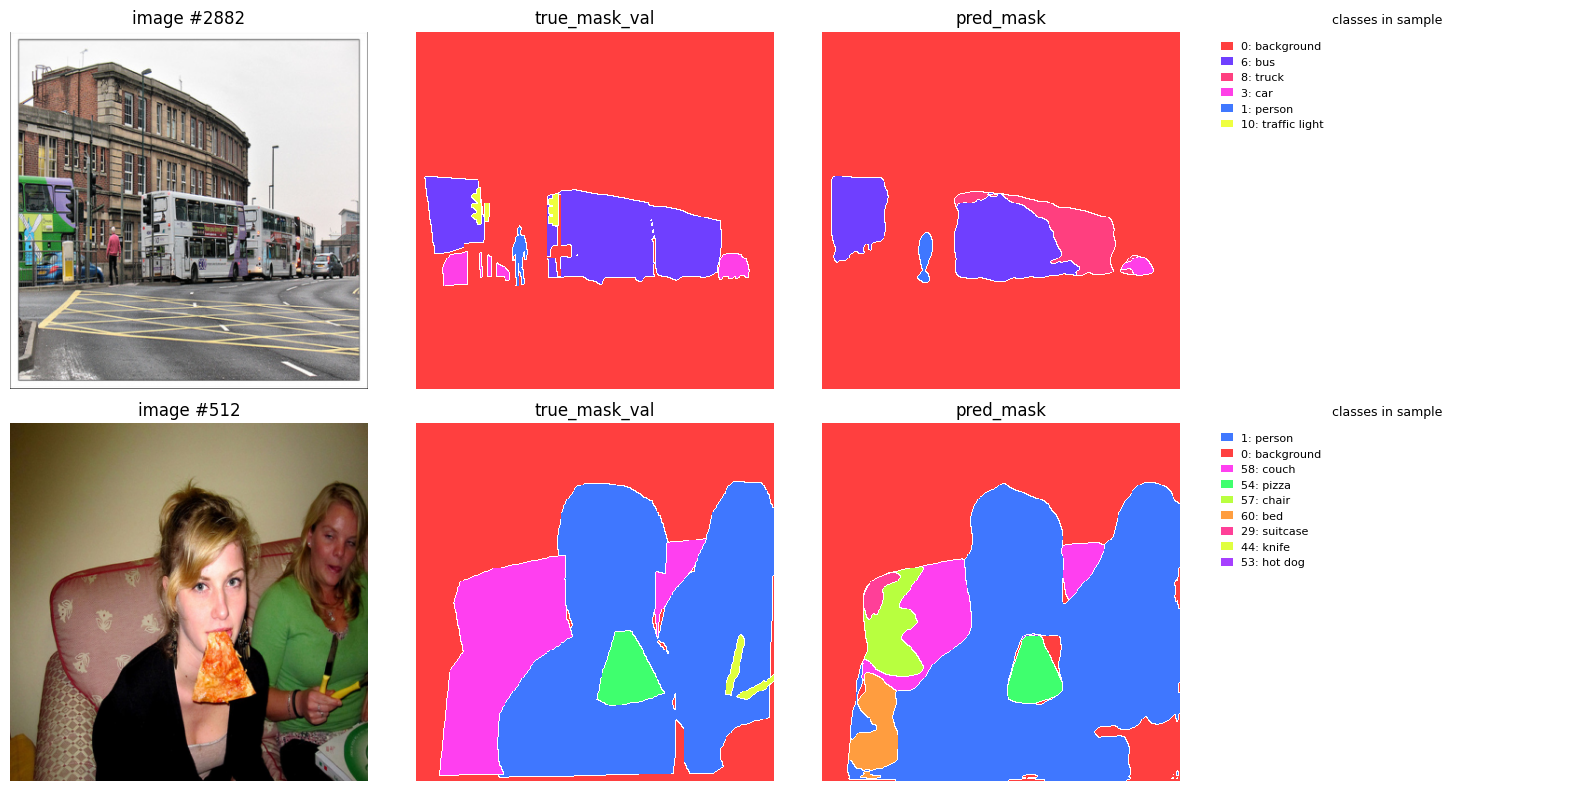

In [11]:
show_val_predictions_triplets(
    model=model,
    val_ds=val_ds,
    device=DEVICE,
    n_samples=2,
    seed=47,
    ignore_index=IGNORE_INDEX,
)

## Получение метрик 

In [12]:
@torch.no_grad()
def per_class_iou(
    model,
    loader,
    device,
    class_names,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    ):
    model.eval()
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    param_dtype = next(model.parameters()).dtype

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        if param_dtype in (torch.float16, torch.bfloat16):
            images = images.to(dtype=param_dtype)
        # if is_half_model:
        #     images = images.half()

        logits = model(images)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present

In [13]:
rows, miou_present = per_class_iou(baseline, val_loader, DEVICE, val_ds.class_names, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX)
print("mIoU (only present classes):", round(miou_present, 4))

for r in rows:
    print(f"{r['class_id']:2d} {r['class_name']:12s} IoU={r['iou']:.3f} present={r['present_in_val']}")


mIoU (only present classes): 0.4525
 0 background   IoU=0.874 present=True
 1 person       IoU=0.769 present=True
 2 bicycle      IoU=0.516 present=True
 3 car          IoU=0.451 present=True
 4 motorcycle   IoU=0.681 present=True
 5 airplane     IoU=0.640 present=True
 6 bus          IoU=0.639 present=True
 7 train        IoU=0.635 present=True
 8 truck        IoU=0.376 present=True
 9 boat         IoU=0.420 present=True
10 traffic light IoU=0.488 present=True
11 fire hydrant IoU=0.738 present=True
12 stop sign    IoU=0.823 present=True
13 parking meter IoU=0.641 present=True
14 bench        IoU=0.336 present=True
15 bird         IoU=0.689 present=True
16 cat          IoU=0.766 present=True
17 dog          IoU=0.664 present=True
18 horse        IoU=0.609 present=True
19 sheep        IoU=0.644 present=True
20 cow          IoU=0.607 present=True
21 elephant     IoU=0.814 present=True
22 bear         IoU=0.808 present=True
23 zebra        IoU=0.864 present=True
24 giraffe      IoU=0.773 

# **torch.compile Experiment**

In [14]:
import json
import time
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

In [15]:
DEVICE_STR = "cuda" if torch.cuda.is_available() else "cpu"

CKPT_PATH = "./weights/checkpoint_coco_fp16.pt"
MODEL_PATH = CKPT_PATH

NUM_CLASSES_EXP = NUM_CLASSES if "NUM_CLASSES" in globals() else 81
IGNORE_INDEX_EXP = IGNORE_INDEX if "IGNORE_INDEX" in globals() else 255
INPUT_SIZE_EXP = IMAGE_SIZE if "IMAGE_SIZE" in globals() else (384, 384)

MODEL_DTYPE = torch.float16

# гиперпараметры benchmark
BENCH_BATCH_SIZES = (1, 2, 4, 8, 16, 32, 64)
METRIC_BATCH_SIZE = 1

WARMUP = 10
ITERS = 30
BENCH_BATCH_SIZE = val_loader.batch_size


COMPILE_CONFIGS = {
    "pytorch_baseline": None,
    "torch_compile_default": {
        "backend": "inductor",
        "mode": "default",
        "dynamic": False,
    },
    "torch_compile_tuned": {
        "backend": "inductor",
        "mode": "max-autotune",
        "dynamic": False,
    },
}


## model initialization

In [16]:
def get_model_param_dtype(model):
    return next(model.parameters()).dtype


def cast_tensor_to_model_dtype(x, model):
    dtype = get_model_param_dtype(model)
    if dtype in (torch.float16, torch.bfloat16, torch.float32):
        return x.to(dtype=dtype)
    return x


def build_model_and_load_ckpt(path=MODEL_PATH, dtype=MODEL_DTYPE, device=DEVICE_STR):
    model = smp.Unet(
        encoder_name="resnet101",
        encoder_weights=None,
        in_channels=3,
        classes=NUM_CLASSES_EXP,
        activation=None,
    )

    state = torch.load(path, map_location="cpu")
    if "model_state_dict" in state:
        state = state["model_state_dict"]
    elif "state_dict" in state:
        state = state["state_dict"]

    model.load_state_dict(state, strict=True)
    model = model.to(dtype=dtype).to(device).eval()

    print("Loaded model dtype:", next(model.parameters()).dtype)
    return model


## Loader для torch.compile

In [17]:
def make_loader_like(base_loader, batch_size, shuffle=False, drop_last=False):
    num_workers = getattr(base_loader, "num_workers", 0)

    kwargs = dict(
        dataset=base_loader.dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=getattr(base_loader, "pin_memory", False),
        collate_fn=base_loader.collate_fn,
        drop_last=drop_last,
    )

    if num_workers > 0 and hasattr(base_loader, "persistent_workers"):
        kwargs["persistent_workers"] = getattr(base_loader, "persistent_workers", False)

    if num_workers > 0 and hasattr(base_loader, "prefetch_factor"):
        prefetch_factor = getattr(base_loader, "prefetch_factor", None)
        if prefetch_factor is not None:
            kwargs["prefetch_factor"] = prefetch_factor

    if hasattr(base_loader, "timeout"):
        kwargs["timeout"] = getattr(base_loader, "timeout", 0)

    return DataLoader(**kwargs)

In [18]:
def make_compile_eval_loader(base_loader):
    kwargs = dict(
        dataset=base_loader.dataset,
        batch_size=base_loader.batch_size,
        shuffle=False,
        num_workers=base_loader.num_workers,
        pin_memory=getattr(base_loader, "pin_memory", False),
        collate_fn=base_loader.collate_fn,
        drop_last=True,
    )

    if hasattr(base_loader, "persistent_workers"):
        kwargs["persistent_workers"] = getattr(base_loader, "persistent_workers", False)

    if hasattr(base_loader, "prefetch_factor"):
        try:
            kwargs["prefetch_factor"] = getattr(base_loader, "prefetch_factor")
        except Exception:
            pass

    if hasattr(base_loader, "timeout"):
        kwargs["timeout"] = getattr(base_loader, "timeout", 0)

    return DataLoader(**kwargs)


## bencmark функции

In [19]:
def get_first_batch_from_loader(loader, device):
    images, _ = next(iter(loader))
    return images.to(device, non_blocking=True)

In [20]:
def get_benchmark_input(loader, batch_size=1, device="cpu"):
    images, _ = next(iter(loader))
    x = images[:batch_size].contiguous()
    return x.to(device)


@torch.no_grad()
def warmup_model(model, x, device, warmup=WARMUP):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    for _ in range(warmup):
        _ = model(x_run)

    if device.startswith("cuda"):
        torch.cuda.synchronize()


@torch.no_grad()
def measure_first_run_compile_overhead(model, x, device):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    if device.startswith("cuda"):
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    _ = model(x_run)
    if device.startswith("cuda"):
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    return float(t1 - t0)


@torch.no_grad()
def benchmark_torch_model(model, x, device, warmup=WARMUP, iters=ITERS):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    # warmup
    for _ in range(warmup):
        _ = model(x_run)
    if device.startswith("cuda"):
        torch.cuda.synchronize()

    times = []
    for _ in range(iters):
        t0 = time.perf_counter()
        _ = model(x_run)
        if device.startswith("cuda"):
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

    times = np.array(times, dtype=np.float64)
    mean_ms = float(times.mean())

    return {
        "latency_ms": mean_ms,
        "throughput_img_s": float(x_run.shape[0] / (mean_ms / 1000.0)),
    }


def benchmark_single_batch_size(model, base_loader, batch_size, device):
    bench_loader = make_loader_like(
        base_loader,
        batch_size=batch_size,
        shuffle=False,
        drop_last=True,
    )

    x_bench = get_first_batch_from_loader(bench_loader, device)
    bench = benchmark_torch_model(
        model,
        x_bench,
        device,
        warmup=WARMUP,
        iters=ITERS,
    )

    return {
        "latency_ms": float(bench["latency_ms"]),
        "throughput_img_s": float(bench["throughput_img_s"]),
    }


def benchmark_all_batch_sizes(model, base_loader, batch_sizes, device):
    batch_results = {}

    for bs in batch_sizes:
        try:
            res = benchmark_single_batch_size(model, base_loader, bs, device)
            batch_results[int(bs)] = res

        except RuntimeError as e:
            err_text = str(e)

            if "out of memory" in err_text.lower():
                print(f"[WARN] OOM for batch_size={bs}: {err_text}")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

                batch_results[int(bs)] = {
                    "latency_ms": np.nan,
                    "throughput_img_s": np.nan,
                    "error": err_text,
                }
            else:
                raise

    return batch_results


@torch.no_grad()
def per_class_iou_compile(
    model,
    loader,
    device,
    num_classes=NUM_CLASSES_EXP,
    ignore_index=IGNORE_INDEX_EXP,
):
    model.eval()
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        images = cast_tensor_to_model_dtype(images, model)

        logits = model(images)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    class_names = None
    if hasattr(loader.dataset, "class_names"):
        class_names = loader.dataset.class_names
    else:
        class_names = [str(i) for i in range(num_classes)]

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present


def evaluate_main_metric(model, base_loader, device, metric_batch_size=1):
    metric_loader = make_loader_like(
        base_loader,
        batch_size=metric_batch_size,
        shuffle=False,
        drop_last=False,
    )

    rows, metric_value = per_class_iou_compile(
        model,
        metric_loader,
        device,
        num_classes=NUM_CLASSES_EXP,
        ignore_index=IGNORE_INDEX_EXP,
    )

    return rows, float(metric_value)

## Главная функция эксперимента

In [21]:
def build_inference_method(method_name, base_model):
    model = deepcopy(base_model).eval()

    if method_name == "pytorch_baseline":
        return model

    cfg = COMPILE_CONFIGS[method_name]
    compiled_model = torch.compile(
        model,
        backend=cfg["backend"],
        mode=cfg["mode"],
        dynamic=cfg["dynamic"],
    )
    return compiled_model

In [22]:
def run_torch_compile_experiment(
    val_loader,
    model_loaded=None,
    checkpoint_path=MODEL_PATH,
    model_dtype=MODEL_DTYPE,
    benchmark_batch_sizes=BENCH_BATCH_SIZES,
    metric_batch_size=METRIC_BATCH_SIZE,
):
    if model_loaded is None:
        model_loaded = build_model_and_load_ckpt(
            path=checkpoint_path,
            dtype=model_dtype,
            device=DEVICE_STR,
        )

    base_model = deepcopy(model_loaded).to(DEVICE_STR).eval()
    native_dtype = get_model_param_dtype(base_model)

    print("Native model dtype:", native_dtype)
    print("Benchmark batch sizes:", benchmark_batch_sizes)
    print("Metric batch size:", metric_batch_size)

    results = {}
    per_class_rows = {}

    for method_name in COMPILE_CONFIGS.keys():
        print(f"\n=== Running method: {method_name} ===")

        if method_name != "pytorch_baseline" and hasattr(torch, "_dynamo"):
            try:
                torch._dynamo.reset()
            except Exception:
                pass

        model_method = build_inference_method(method_name, base_model)

        # 1. benchmark по batch_size
        batch_results = benchmark_all_batch_sizes(
            model=model_method,
            base_loader=val_loader,
            batch_sizes=benchmark_batch_sizes,
            device=DEVICE_STR,
        )

        # 2. главная метрика — один раз на фиксированном batch size
        rows, metric_value = evaluate_main_metric(
            model=model_method,
            base_loader=val_loader,
            device=DEVICE_STR,
            metric_batch_size=metric_batch_size,
        )

        results[method_name] = {
            "dtype": str(native_dtype).replace("torch.", ""),
            "main_metric_name": "mIoU",
            "main_metric": float(metric_value),
            "batch_results": batch_results,
        }

        per_class_rows[method_name] = rows

        del model_method
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\n=== RAW RESULTS ===")
    print(json.dumps(results, indent=2, ensure_ascii=False))

    return {
        "results": results,
        "per_class_rows": per_class_rows,
    }

## Функции отображения результатов

In [60]:
def show_torch_compile_report(
    exp_out,
    title="Отчет по сравнению инференса",
    baseline_method="pytorch_baseline",
    batch_sizes=(1, 2, 4, 8, 16, 32, 64),
):
    if isinstance(exp_out, dict) and "results" in exp_out:
        results = exp_out["results"]
    else:
        results = exp_out

    def _extract_main_metric(vals):
        if "main_metric" in vals:
            return vals.get("main_metric_name", "Main metric"), float(vals["main_metric"])
        if "miou_present" in vals:
            return "mIoU", float(vals["miou_present"])
        return "Main metric", np.nan

    def _infer_batch_size_from_old_format(vals):
        if "benchmark_batch_size" in vals:
            try:
                return int(vals["benchmark_batch_size"])
            except Exception:
                pass

        if "latency_ms" in vals and "throughput_img_s" in vals:
            try:
                bs = vals["throughput_img_s"] * vals["latency_ms"] / 1000.0
                bs = int(round(bs))
                if bs > 0:
                    return bs
            except Exception:
                pass

        return None

    rows_latency = []
    rows_throughput = []
    rows_metric = []
    errors = []

    method_order = [
        "pytorch_baseline",
        "torch_compile_default",
        "torch_compile_tuned",
        "tvm_relax_tir"
    ]

    pretty_names_ru = {
        "pytorch_baseline": "Оригинальная\n",
        "torch_compile_default": "torch.compile\n(default)",
        "torch_compile_tuned": "torch.compile\n(tuned)",
        "tvm_relax_tir": "TVM Relax"
    }

    pretty_names_table = {
        "pytorch_baseline": "Оригинальная модель",
        "torch_compile_default": "Компиляция torch (torch.compile default)",
        "torch_compile_tuned": "Компиляция torch с подобранными параметрами (torch.compile tuned)",
        "tvm_relax_tir": "TVM Relax"
    }

    for method, vals in results.items():
        if not isinstance(vals, dict):
            errors.append({"method": method, "error": f"Unexpected value type: {type(vals)}"})
            continue

        if "error" in vals:
            errors.append({"method": method, "error": vals["error"]})
            continue

        dtype = vals.get("dtype", "")
        metric_name, metric_value = _extract_main_metric(vals)


        if "batch_results" in vals or "batch_benchmarks" in vals:
            if "batch_results" in vals:
                batch_results = vals["batch_results"]
            else:
                batch_results = vals["batch_benchmarks"]
            batch_results_norm = {}
            for k, v in batch_results.items():
                try:
                    batch_results_norm[int(k)] = v
                except Exception:
                    pass

            if 1 in batch_results_norm and "latency_ms" in batch_results_norm[1]:
                latency_1img_ms = float(batch_results_norm[1]["latency_ms"])
            else:
                available_bs = sorted(batch_results_norm.keys())
                if len(available_bs) == 0:
                    errors.append({"method": method, "error": "batch_results пустой"})
                    continue
                bs0 = available_bs[0]
                if "latency_ms" not in batch_results_norm[bs0]:
                    errors.append({"method": method, "error": f"Для batch={bs0} нет latency_ms"})
                    continue
                latency_1img_ms = float(batch_results_norm[bs0]["latency_ms"]) / bs0

            rows_latency.append({
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
                "latency_1img_ms": latency_1img_ms,
            })

            thr_row = {
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
            }
            for bs in batch_sizes:
                if bs in batch_results_norm and "throughput_img_s" in batch_results_norm[bs]:
                    thr_row[f"throughput_bs{bs}"] = float(batch_results_norm[bs]["throughput_img_s"])
                else:
                    thr_row[f"throughput_bs{bs}"] = np.nan
            rows_throughput.append(thr_row)


        else:
            required_keys = ["latency_ms", "throughput_img_s"]
            missing = [k for k in required_keys if k not in vals]
            if missing:
                errors.append({"method": method, "error": f"Missing keys: {missing}"})
                continue

            inferred_bs = _infer_batch_size_from_old_format(vals)
            if inferred_bs is None:
                errors.append({
                    "method": method,
                    "error": "Не удалось восстановить benchmark_batch_size из latency_ms и throughput_img_s"
                })
                continue

            latency_1img_ms = float(vals["latency_ms"]) / inferred_bs

            rows_latency.append({
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
                "latency_1img_ms": latency_1img_ms,
            })

            thr_row = {
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
            }
            for bs in batch_sizes:
                thr_row[f"throughput_bs{bs}"] = np.nan


            if inferred_bs in batch_sizes:
                thr_row[f"throughput_bs{inferred_bs}"] = float(vals["throughput_img_s"])

            rows_throughput.append(thr_row)

        rows_metric.append({
            "method": method,
            "pretty_method": pretty_names_ru.get(method, method),
            "pretty_method_table": pretty_names_table.get(method, method),
            "dtype": dtype,
            "metric_name": metric_name,
            "main_metric": metric_value,
            "main_metric_percent": metric_value * 100.0 if pd.notna(metric_value) else np.nan,
        })

    latency_df = pd.DataFrame(rows_latency)
    throughput_df = pd.DataFrame(rows_throughput)
    metric_df = pd.DataFrame(rows_metric)
    err_df = pd.DataFrame(errors)

    if latency_df.empty and throughput_df.empty and metric_df.empty:
        print("Нет валидных результатов.")
        if not err_df.empty:
            display(err_df)
        return {
            "latency_df": latency_df,
            "throughput_df": throughput_df,
            "metric_df": metric_df,
            "errors_df": err_df,
        }

    def _sort_df(df):
        if df.empty:
            return df
        df["method"] = pd.Categorical(df["method"], categories=method_order, ordered=True)
        return df.sort_values("method").reset_index(drop=True)

    latency_df = _sort_df(latency_df)
    throughput_df = _sort_df(throughput_df)
    metric_df = _sort_df(metric_df)

    # baseline
    if baseline_method in metric_df["method"].astype(str).tolist():
        baseline_metric = metric_df.loc[metric_df["method"] == baseline_method, "main_metric"].iloc[0]
        metric_df["main_metric_delta_pp"] = metric_df["main_metric_percent"] - baseline_metric * 100.0
    else:
        metric_df["main_metric_delta_pp"] = np.nan

    if baseline_method in latency_df["method"].astype(str).tolist():
        baseline_latency = latency_df.loc[latency_df["method"] == baseline_method, "latency_1img_ms"].iloc[0]
        latency_df["latency_speedup_vs_baseline"] = baseline_latency / latency_df["latency_1img_ms"]
    else:
        latency_df["latency_speedup_vs_baseline"] = np.nan

    # Таблица 1. Latency per image
    latency_table = latency_df[[
        "pretty_method_table",
        "dtype",
        "latency_1img_ms",
        "latency_speedup_vs_baseline",
    ]].copy()

    latency_table = latency_table.rename(columns={
        "pretty_method_table": "Метод (Method)",
        "dtype": "Тип данных модели (Model dtype)",
        "latency_1img_ms": "Средняя задержка инференса 1 изображения, мс",
        "latency_speedup_vs_baseline": "Ускорение относительно baseline",
    })

    print("=== Таблица 1. Средняя задержка инференса 1 изображения ===")
    display(latency_table)


    # Таблица 2. Throughput
    thr_cols = ["pretty_method_table", "dtype"] + [f"throughput_bs{bs}" for bs in batch_sizes]
    throughput_table = throughput_df[thr_cols].copy()

    rename_thr = {
        "pretty_method_table": "Метод (Method)",
        "dtype": "Тип данных модели (Model dtype)",
    }
    for bs in batch_sizes:
        rename_thr[f"throughput_bs{bs}"] = f"Пропускная способность при batch_size={bs}, изображений/с"

    throughput_table = throughput_table.rename(columns=rename_thr)

    print("=== Таблица 2. Пропускная способность ===")
    display(throughput_table)


    # Таблица 3. Главная метрика
    metric_table = metric_df[[
        "pretty_method_table",
        "dtype",
        "metric_name",
        "main_metric_percent",
        "main_metric_delta_pp",
    ]].copy()

    metric_table = metric_table.rename(columns={
        "pretty_method_table": "Метод (Method)",
        "dtype": "Тип данных модели (Model dtype)",
        "metric_name": "Главная метрика",
        "main_metric_percent": "Значение главной метрики, %",
        "main_metric_delta_pp": "Изменение относительно baseline, п.п.",
    })

    print("=== Таблица 3. Изменение главной метрики ===")
    display(metric_table)

    if not err_df.empty:
        print("\n=== Ошибки / предупреждения ===")
        display(err_df)


    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(title, fontsize=14)

    # 1. latency per image
    ax = axes[0]
    bars = ax.bar(latency_df["pretty_method"], latency_df["latency_1img_ms"])
    ax.set_title("Latency (ms)")
    ax.set_ylabel("мс")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, latency_df["latency_1img_ms"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)

    # 2. throughput vs batch size
    ax = axes[1]
    for _, row in throughput_df.iterrows():
        ys = [row[f"throughput_bs{bs}"] for bs in batch_sizes]

        ax.plot(batch_sizes, ys, marker="o", linewidth=2, label=row["pretty_method"])

        # подписи прямо над точками
        for x, y in zip(batch_sizes, ys):
            if pd.notna(y):
                ax.text(
                    x, y,
                    f"bs={x}",
                    fontsize=9,
                    ha="center",
                    va="bottom"
                )

    ax.set_title("Throughput / Пропускная способность при разных batch size")
    ax.set_xlabel("batch size")
    ax.set_ylabel("изображений/с")
    ax.set_xticks(batch_sizes)  # явно показываем нужные batch size
    ax.set_xticklabels([str(bs) for bs in batch_sizes])
    ax.grid(alpha=0.3)
    ax.legend()

    # 3. абсолютное значение главной метрики
    ax = axes[2]
    bars = ax.bar(metric_df["pretty_method"], metric_df["main_metric_percent"])
    metric_name_for_title = metric_df["metric_name"].iloc[0] if not metric_df.empty else "главной метрики"
    ax.set_title(f"Значение {metric_name_for_title}")
    ax.set_ylabel("%")
    ax.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, metric_df["main_metric_percent"]):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.4f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


    return latency_df, throughput_df, metric_df, err_df

In [24]:
def show_per_class_iou(exp_out, method_name="pytorch_baseline", top_k=15):
    if "per_class_rows" not in exp_out:
        raise ValueError("В exp_out нет per_class_rows")

    if method_name not in exp_out["per_class_rows"]:
        raise ValueError(f"Метод {method_name} не найден")

    rows = exp_out["per_class_rows"][method_name]
    df = pd.DataFrame(rows)

    df = df.sort_values("iou", ascending=False).reset_index(drop=True)

    print(f"=== Per-class IoU для {method_name} ===")
    display(df.head(top_k))
    return df

## Результаты

In [25]:
baseline = build_model_and_load_ckpt(
    path=MODEL_PATH,
    dtype=MODEL_DTYPE,
    device=DEVICE_STR,
)

Loaded model dtype: torch.float16


In [26]:
exp_compile = run_torch_compile_experiment(
    val_loader=val_loader,
    model_loaded=baseline,
)

Native model dtype: torch.float16
Benchmark batch sizes: (1, 2, 4, 8, 16, 32, 64)
Metric batch size: 1

=== Running method: pytorch_baseline ===

=== Running method: torch_compile_default ===

=== Running method: torch_compile_tuned ===

=== RAW RESULTS ===
{
  "pytorch_baseline": {
    "dtype": "float16",
    "main_metric_name": "mIoU",
    "main_metric": 0.4524500370025635,
    "batch_results": {
      "1": {
        "latency_ms": 19.59604847555359,
        "throughput_img_s": 51.03069637980929
      },
      "2": {
        "latency_ms": 18.136888121565182,
        "throughput_img_s": 110.27250025443745
      },
      "4": {
        "latency_ms": 17.55381819481651,
        "throughput_img_s": 227.8706521627964
      },
      "8": {
        "latency_ms": 20.092760864645243,
        "throughput_img_s": 398.15334756094245
      },
      "16": {
        "latency_ms": 27.35749740774433,
        "throughput_img_s": 584.8488171827712
      },
      "32": {
        "latency_ms": 52.571008478

=== Таблица 1. Средняя задержка инференса 1 изображения ===


,Метод (Method),Тип данных модели (Model dtype),"Средняя задержка инференса 1 изображения, мс",Ускорение относительно baseline
0,Оригинальная модель,float16,19.596048,1.000000
1,Компиляция torch (torch.compile default),float16,5.696743,3.439869
2,Компиляция torch с подобранными параметрами (t...,float16,2.577773,7.601929


=== Таблица 2. Пропускная способность ===


,Метод (Method),Тип данных модели (Model dtype),"Пропускная способность при batch_size=1, изображений/с","Пропускная способность при batch_size=2, изображений/с","Пропускная способность при batch_size=4, изображений/с","Пропускная способность при batch_size=8, изображений/с","Пропускная способность при batch_size=16, изображений/с","Пропускная способность при batch_size=32, изображений/с","Пропускная способность при batch_size=64, изображений/с"
0,Оригинальная модель,float16,51.030696,110.272500,227.870652,398.153348,584.848817,608.700516,621.197124
1,Компиляция torch (torch.compile default),float16,175.538908,299.885319,547.198848,874.000950,972.505040,1014.049062,1057.826575
2,Компиляция torch с подобранными параметрами (t...,float16,387.931709,676.092485,880.769186,980.279583,1075.941852,1171.471918,1179.127014


=== Таблица 3. Изменение главной метрики ===


,Метод (Method),Тип данных модели (Model dtype),Главная метрика,"Значение главной метрики, %","Изменение относительно baseline, п.п."
0,Оригинальная модель,float16,mIoU,45.245004,0.000000
1,Компиляция torch (torch.compile default),float16,mIoU,45.245135,0.000131
2,Компиляция torch с подобранными параметрами (t...,float16,mIoU,45.244956,-0.000048


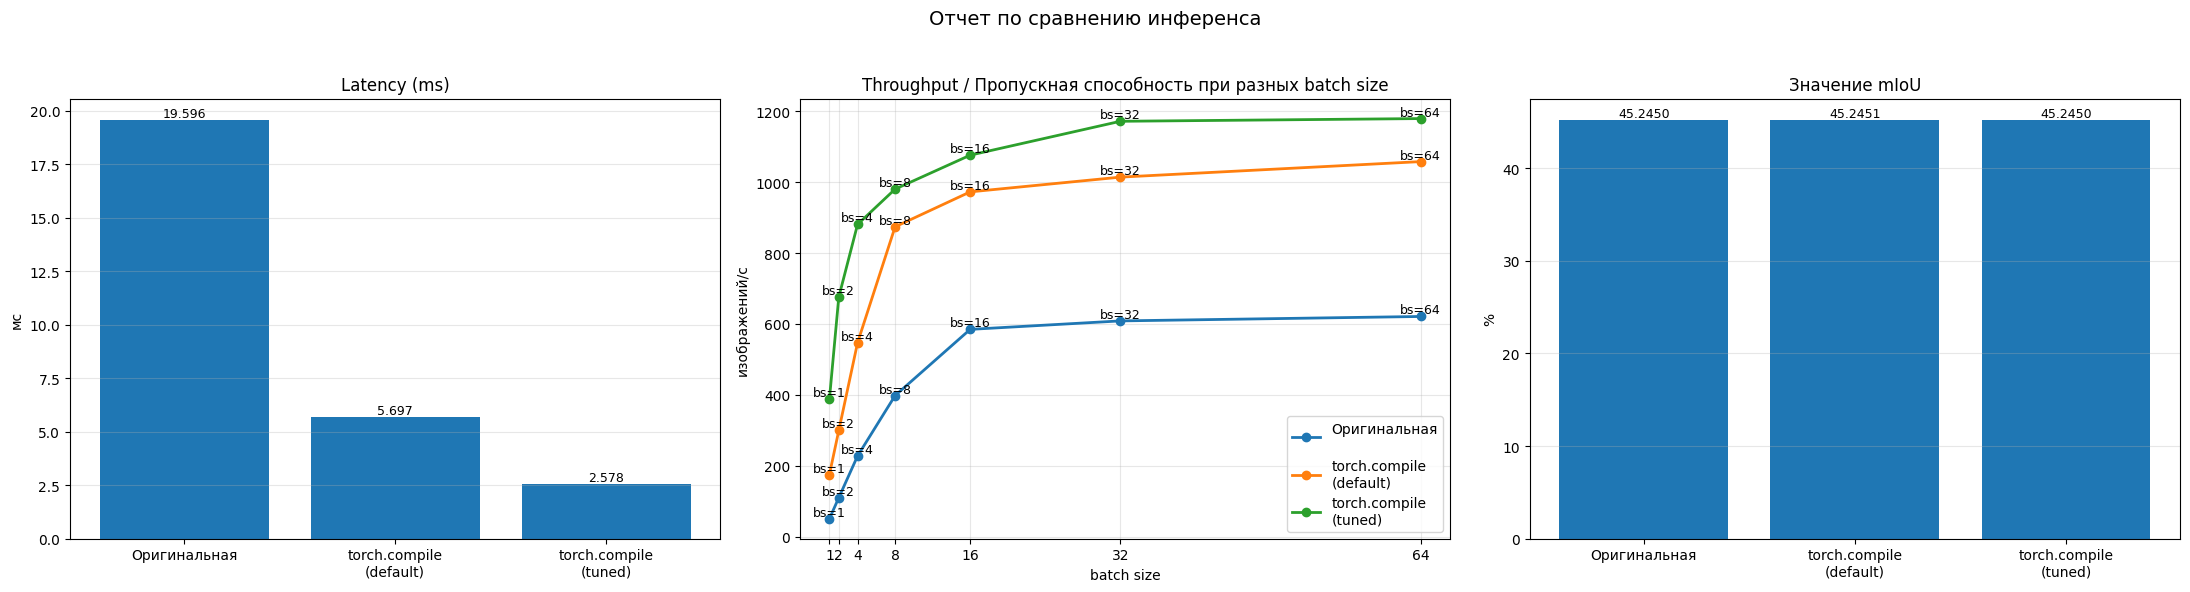

In [27]:
latency_df, throughput_df, metric_df, err_df = show_torch_compile_report(exp_compile)

# **TVM Experiment**

## **0. Imports**

In [28]:
import os, shutil, subprocess

CUDA_HOME = "/usr/local/cuda-12.6"

os.environ["CUDA_HOME"] = CUDA_HOME
os.environ["PATH"] = f"{CUDA_HOME}/bin:" + os.environ.get("PATH", "")
os.environ["LD_LIBRARY_PATH"] = (
    f"{CUDA_HOME}/lib64:{CUDA_HOME}/targets/x86_64-linux/lib:"
    + os.environ.get("LD_LIBRARY_PATH", "")
)

print("CUDA_HOME:", os.environ["CUDA_HOME"])
print("nvcc in PATH:", shutil.which("nvcc"))
print(subprocess.run(["nvcc", "--version"], capture_output=True, text=True, check=True).stdout)

CUDA_HOME: /usr/local/cuda-12.6
nvcc in PATH: /usr/local/cuda-12.6/bin/nvcc
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Tue_Oct_29_23:50:19_PDT_2024
Cuda compilation tools, release 12.6, V12.6.85
Build cuda_12.6.r12.6/compiler.35059454_0



In [29]:
import os, shutil, tvm
from tvm.contrib import nvcc as tvm_nvcc

print("CUDA_HOME:", os.environ.get("CUDA_HOME"))
print("nvcc:", shutil.which("nvcc"))
print("TVM CUDA path:", tvm_nvcc.find_cuda_path())
print("TVM CUDA version:", tvm_nvcc.get_cuda_version())
print("CUDA exist:", tvm.cuda(0).exist)

CUDA_HOME: /usr/local/cuda-12.6
nvcc: /usr/local/cuda-12.6/bin/nvcc
TVM CUDA path: /usr/local/cuda-12.6
TVM CUDA version: (12, 6, 85)
CUDA exist: True


In [30]:
import json
import time
from copy import deepcopy

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

import tvm
from tvm import relax
from tvm.relax.frontend.torch import from_exported_program
from torch.export import export

from tvm.s_tir import dlight as dl

In [31]:
DEVICE_STR = "cuda"

MODEL_PATH = globals().get(
    "MODEL_PATH",
    globals().get("CKPT_PATH", "./weights/checkpoint_coco_fp16.pt")
)

# ignore index для val mask
IGNORE_INDEX_EXP = globals().get("IGNORE_INDEX_EXP", globals().get("IGNORE_INDEX", 255))

# batch для benchmark
BATCH_SIZE_BENCH = globals().get("BATCH_SIZE_BENCH", 1)

# TVM tuning
TVM_TUNE = False
TVM_TOTAL_TRIALS = globals().get("TVM_TOTAL_TRIALS", 128)
TVM_MAX_TRIALS_PER_TASK = globals().get("TVM_MAX_TRIALS_PER_TASK", 16)
TVM_WORK_DIR = globals().get("TVM_WORK_DIR", "tvm_tuning_logs")

FAST_DEBUG_MAX_IOU_BATCHES = globals().get("FAST_DEBUG_MAX_IOU_BATCHES", None)

## **1. Вспомогательные функции**

In [ ]:
def maybe_limit_loader(loader, max_batches=None):
    if max_batches is None:
        for batch in loader:
            yield batch
    else:
        for i, batch in enumerate(loader):
            if i >= max_batches:
                break
            yield batch


def tensor_to_numpy_float32(x):
    """
    Приведение torch.Tensor / tvm.runtime.Tensor / ndarray к np.float32.
    """
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy().astype("float32")
    if hasattr(x, "numpy"):
        return x.numpy().astype("float32")
    return np.asarray(x, dtype="float32")


def tvm_obj_to_numpy(x):
    """
    TVM VM может вернуть Tensor или tuple/list с Tensor.
    """
    if isinstance(x, (list, tuple)):
        x = x[0]
    if hasattr(x, "numpy"):
        return x.numpy()
    return np.asarray(x)


def get_tvm_target_and_device():
    print("torch.cuda.is_available() =", torch.cuda.is_available())
    print("tvm.runtime.enabled('cuda') =", tvm.runtime.enabled("cuda"))

    dev = tvm.cuda(0)
    print("tvm.cuda(0).exist =", dev.exist)

    if not tvm.runtime.enabled("cuda"):
        raise RuntimeError("TVM собран или загружен без поддержки CUDA")

    if not dev.exist:
        raise RuntimeError("TVM не видит GPU через tvm.cuda(0)")

    return tvm.target.Target("cuda"), dev, "cuda"


def get_benchmark_input(val_loader, batch_size=1, device="cpu"):
    """
    Берем первый батч из val_loader и используем его как benchmark input.
    """
    images, _ = next(iter(val_loader))
    x = images[:batch_size].contiguous()
    return x.to(device)


def to_tvm_nd(x, dev):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    elif not isinstance(x, np.ndarray):
        x = np.array(x)

    x = np.ascontiguousarray(x)
    return tvm.nd.array(x, device=dev)



def to_tvm_tensor(x, dev):

    if isinstance(x, torch.Tensor):
        t = x.detach().contiguous()
        if getattr(dev, "type", None) == "cuda":
            t = t.to("cuda")
        else:
            t = t.cpu()
        return t

    if not isinstance(x, np.ndarray):
        x = np.array(x)

    x = np.ascontiguousarray(x)

    if hasattr(tvm, "nd") and hasattr(tvm.nd, "array"):
        return tvm.nd.array(x, device=dev)

    if (
        hasattr(tvm, "runtime")
        and hasattr(tvm.runtime, "ndarray")
        and hasattr(tvm.runtime.ndarray, "array")
    ):
        return tvm.runtime.ndarray.array(x, device=dev)

    t = torch.from_numpy(x).contiguous()
    if getattr(dev, "type", None) == "cuda":
        t = t.to("cuda")
    else:
        t = t.cpu()
    return t


def tensor_to_numpy_float32(x):
    import numpy as np
    import torch

    if isinstance(x, np.ndarray):
        return np.ascontiguousarray(x.astype("float32", copy=False))

    if isinstance(x, torch.Tensor):
        return np.ascontiguousarray(
            x.detach().float().cpu().numpy()
        )

    # если это не torch.Tensor и не np.ndarray
    return np.ascontiguousarray(np.array(x, dtype=np.float32))

## **2. TVM Model**

In [33]:
def get_tvm_target_and_device():
    dev = tvm.cuda(0)
    target = tvm.target.Target.from_device(dev)
    return target, dev, str(target)


def tensor_to_numpy_float32(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().float().numpy()
    if isinstance(x, np.ndarray):
        return x.astype(np.float32, copy=False)
    if hasattr(x, "numpy"):
        arr = x.numpy()
        if isinstance(arr, np.ndarray):
            return arr.astype(np.float32, copy=False)
    return np.array(x, dtype=np.float32)

def load_master_model(path=MODEL_PATH):
    model = smp.Unet(
        encoder_name="resnet101",
        encoder_weights=None,
        in_channels=3,
        classes=NUM_CLASSES,
        activation=None,
    )

    state = torch.load(path, map_location="cpu")

    if "model_state_dict" in state:
        state = state["model_state_dict"]
    elif "state_dict" in state:
        state = state["state_dict"]

    model.load_state_dict(state, strict=True)
    model = model.float().cpu().eval()

    print("Loaded master model dtype:", next(model.parameters()).dtype)
    return model


def build_tvm_vm(master_model, input_shape):
    model_for_export = deepcopy(master_model).float().cpu().eval()

    print("TVM export model dtype:", next(model_for_export.parameters()).dtype)
    example = (torch.randn(*input_shape, dtype=torch.float32),)
    print("TVM export example dtype:", example[0].dtype)

    with torch.no_grad():
        exported_program = export(model_for_export, example)
        mod = from_exported_program(exported_program, keep_params_as_input=True)

    mod, params = relax.frontend.detach_params(mod)

    target, dev_tvm, tvm_target_name = get_tvm_target_and_device()


    with target:
        mod = tvm.ir.transform.Sequential([
            relax.get_pipeline("zero"),
            dl.ApplyDefaultSchedule(
                dl.gpu.Matmul(),
                dl.gpu.GEMV(),
                dl.gpu.Reduction(),
                dl.gpu.GeneralReduction(),
                dl.gpu.Fallback(),
            ),
        ])(mod)


    # if TVM_TUNE:
    #     with target:
    #         mod = tvm.ir.transform.Sequential([
    #             relax.get_pipeline("zero"),
    #             relax.transform.MetaScheduleTuneTIR(
    #                 work_dir=TVM_WORK_DIR,
    #                 max_trials_global=TVM_TOTAL_TRIALS,
    #             ),
    #             relax.transform.MetaScheduleApplyDatabase(
    #                 work_dir=TVM_WORK_DIR
    #             ),
    #         ])(mod)

    ex = tvm.compile(mod, target=target)
    vm = relax.VirtualMachine(ex, dev_tvm)

    params_np = [tensor_to_numpy_float32(p) for p in params["main"]]
    return vm, params_np, dev_tvm, tvm_target_name

## **3. Inference & benchmark**

In [ ]:
def benchmark_tvm(vm, params_tvm, dev_tvm, x_bench):
    x_np = x_bench.detach().float().cpu().numpy().astype("float32", copy=False)

    # set_input поддерживает np.ndarray
    vm.set_input("main", x_np, *params_tvm)

    # Документированный способ бенчмарка stateful API
    timer = vm.time_evaluator("invoke_stateful", dev_tvm, number=10, repeat=20)
    res = timer("main")

    times_ms = np.array(res.results, dtype=np.float64) * 1000.0
    mean_ms = float(times_ms.mean())

    return {
        "latency_ms": mean_ms,
        "p50_ms": float(np.percentile(times_ms, 50)),
        "p95_ms": float(np.percentile(times_ms, 95)),
        "throughput_img_s": float(x_bench.shape[0] / (mean_ms / 1000.0)),
    }


@torch.no_grad()
def per_class_iou_tvm_same_as_baseline(
    vm,
    params_tvm,
    dev_tvm,
    loader,
    num_classes,
    ignore_index=255,
    max_batches=None,
):
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64)

    for bidx, (images, masks) in enumerate(loader):
        if max_batches is not None and bidx >= max_batches:
            break

        x_np = images.detach().float().cpu().numpy().astype("float32", copy=False)

        vm.set_input("main", x_np, *params_tvm)
        vm.invoke_stateful("main")
        out = vm.get_outputs("main")

        out_np = tvm_obj_to_numpy(out)
        logits = torch.from_numpy(out_np)

        preds = logits.argmax(dim=1)
        masks = masks.cpu()

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present

## **4. Главная функция эксперимента**

In [36]:
def make_tvm_eval_loader(base_loader, batch_size=1):
    return DataLoader(
        base_loader.dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=base_loader.num_workers,
        pin_memory=getattr(base_loader, "pin_memory", False),
        persistent_workers=False,
        collate_fn=getattr(base_loader, "collate_fn", None),
    )

In [37]:
import gc

TVM_BENCH_BATCH_SIZES = (1, 2, 4, 8, 16, 32, 64)


THROUGHPUT_KEY_FMT = "throughput_bs{bs}_img_s"
LATENCY_KEY_FMT = "latency_bs{bs}_ms"


def get_tvm_bench_input_for_batch_size(val_loader, batch_size):
    loader_bs = make_tvm_eval_loader(val_loader, batch_size=batch_size)
    x_bench_bs = get_benchmark_input(
        loader_bs,
        batch_size=batch_size,
        device=DEVICE_STR,
    )
    return x_bench_bs, loader_bs


def benchmark_tvm_batch_grid(master_model, val_loader, batch_sizes=TVM_BENCH_BATCH_SIZES):
    batch_results = {}
    last_target_name = None

    for bs in batch_sizes:
        print(f"[TVM] benchmark batch_size={bs}")

        vm_bs = None
        params_bs = None
        x_bench_bs = None

        try:
            x_bench_bs, _ = get_tvm_bench_input_for_batch_size(val_loader, bs)

            vm_bs, params_bs, dev_bs, target_name = build_tvm_vm(
                master_model,
                input_shape=tuple(x_bench_bs.shape),
            )
            last_target_name = target_name

            batch_results[bs] = benchmark_tvm(vm_bs, params_bs, dev_bs, x_bench_bs)

        except Exception as e:
            batch_results[bs] = {"error": str(e)}

        finally:
            try:
                del vm_bs
            except:
                pass
            try:
                del params_bs
            except:
                pass
            try:
                del x_bench_bs
            except:
                pass

            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return batch_results, last_target_name


def add_tvm_batch_metrics_to_result(tvm_result, batch_results):
    if "batch_benchmarks" not in tvm_result:
        tvm_result["batch_benchmarks"] = {}

    for bs, res in batch_results.items():
        if "error" in res:
            tvm_result["batch_benchmarks"][bs] = {"error": res["error"]}
            continue

        throughput_key = f"throughput_batch_size_{bs}"
        latency_key = f"latency_batch_size_{bs}"

        tvm_result[throughput_key] = float(res["throughput_img_s"])
        tvm_result[latency_key] = float(res["latency_ms"])

        tvm_result["batch_benchmarks"][bs] = {
            "latency_ms": float(res["latency_ms"]),
            "throughput_img_s": float(res["throughput_img_s"]),
        }

    return tvm_result

In [38]:
def run_tvm_experiment(val_loader, bench_batch_sizes=TVM_BENCH_BATCH_SIZES):
    master_model = load_master_model(MODEL_PATH)


    tvm_loader_eval = make_tvm_eval_loader(val_loader, batch_size=1)

    x_bench = get_benchmark_input(
        tvm_loader_eval,
        batch_size=1,
        device=DEVICE_STR,
    )

    print("TVM benchmark/eval input shape:", tuple(x_bench.shape))

    vm, params_tvm, dev_tvm, tvm_target_name = build_tvm_vm(
        master_model,
        input_shape=tuple(x_bench.shape),
    )

    print("TVM target:", tvm_target_name)

    tvm_result = benchmark_tvm(vm, params_tvm, dev_tvm, x_bench)

    tvm_rows, tvm_miou = per_class_iou_tvm_same_as_baseline(
        vm,
        params_tvm,
        dev_tvm,
        tvm_loader_eval,   # batch_size=1
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX_EXP,
        max_batches=FAST_DEBUG_MAX_IOU_BATCHES,
    )

    tvm_result["miou_present"] = float(tvm_miou)
    tvm_result["target"] = tvm_target_name
    tvm_result["runtime_dtype"] = "float32"
    tvm_result["eval_batch_size"] = 1


    batch_results = {
        1: {
            "latency_ms": float(tvm_result["latency_ms"]),
            "throughput_img_s": float(tvm_result["throughput_img_s"]),
        }
    }

    other_batch_sizes = tuple(bs for bs in bench_batch_sizes if bs != 1)
    if len(other_batch_sizes) > 0:
        more_batch_results, _ = benchmark_tvm_batch_grid(
            master_model,
            val_loader,
            batch_sizes=other_batch_sizes,
        )
        batch_results.update(more_batch_results)

    tvm_result = add_tvm_batch_metrics_to_result(tvm_result, batch_results)

    print(json.dumps({"tvm_relax_tir": tvm_result}, indent=2, ensure_ascii=False))

    return {
        "results": {
            "tvm_relax_tir": tvm_result
        },
        "tvm_rows": tvm_rows,
        "tvm_batch_benchmarks": batch_results,
    }

## **5. Vizualization**

In [39]:
def show_val_predictions_triplets_tvm(
    vm,
    params_vm,
    dev_tvm,
    val_ds,
    n_samples=4,
    seed=42,
    ignore_index=IGNORE_INDEX,
):
    rng = random.Random(seed)
    idxs = [rng.randrange(len(val_ds)) for _ in range(n_samples)]

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    num_classes = val_ds.num_classes
    ignore_show_id = num_classes
    cmap, norm = _build_seg_cmap_with_ignore(num_classes)

    fig, axes = plt.subplots(
        n_samples, 4, figsize=(16, 4 * n_samples),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.9]}
    )
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, idx in enumerate(idxs):
        image, true_mask = val_ds[idx]

        x_np = image.unsqueeze(0).detach().cpu().numpy().astype("float32")
        out = vm["main"](x_np, *params_vm)
        out_np = tvm_obj_to_numpy(out)

        pred_mask = out_np.argmax(axis=1)[0]

        img_show = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        true_show = true_mask.cpu().numpy().copy()
        true_show[true_show == ignore_index] = ignore_show_id

        axes[i, 0].imshow(img_show)
        axes[i, 0].set_title(f"image #{idx}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(true_show, cmap=cmap, norm=norm, interpolation="nearest")
        axes[i, 1].imshow(_boundary_rgba(true_show), interpolation="nearest")
        axes[i, 1].set_title("true_mask_val")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_mask, cmap=cmap, norm=norm, interpolation="nearest")
        axes[i, 2].imshow(_boundary_rgba(pred_mask), interpolation="nearest")
        axes[i, 2].set_title("pred_mask_tvm")
        axes[i, 2].axis("off")

        ids, counts = np.unique(np.concatenate([true_show.ravel(), pred_mask.ravel()]), return_counts=True)
        order = np.argsort(-counts)

        axes[i, 3].axis("off")
        lines = []
        for cls_id in ids[order][:10]:
            if cls_id == ignore_show_id:
                name = "ignore"
                show_id = 255
            else:
                name = val_ds.class_names[int(cls_id)]
                show_id = int(cls_id)
            lines.append(f"{show_id}: {name}")

        axes[i, 3].text(
            0.0, 1.0,
            "\n".join(lines),
            va="top",
            ha="left",
            fontsize=10,
            family="monospace",
        )

    plt.tight_layout()
    plt.show()

## **6. Results**

In [51]:
def append_tvm_to_existing_results(exp_compile, exp_tvm):
    merged = deepcopy(exp_compile)

    tvm_result = exp_tvm["results"]["tvm_relax_tir"]
    tvm_batch = exp_tvm.get("tvm_batch_benchmarks", tvm_result.get("batch_benchmarks", {}))

    if "results" in merged and isinstance(merged["results"], dict):
        merged["results"]["tvm_relax_tir"] = tvm_result
    else:
        merged["tvm_relax_tir"] = tvm_result

    if "batch_benchmarks" in merged and isinstance(merged["batch_benchmarks"], dict):
        merged["batch_benchmarks"]["tvm_relax_tir"] = tvm_batch
    else:
        merged["batch_benchmarks"] = {"tvm_relax_tir": tvm_batch}

    if "tvm_rows" in exp_tvm:
        merged["tvm_rows"] = exp_tvm["tvm_rows"]

    return merged

In [41]:
exp_tvm = run_tvm_experiment(
    val_loader,
    bench_batch_sizes=(1, 2, 4, 8, 16, 32, 64)
)

Loaded master model dtype: torch.float32
TVM benchmark/eval input shape: (1, 3, 384, 384)
TVM export model dtype: torch.float32
TVM export example dtype: torch.float32


/home/apotapenko/miniconda3/envs/tvm-env/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


TVM target: {"kind":"cuda","tag":"","keys":["cuda","gpu"],"max_num_threads":1024,"thread_warp_size":32,"max_shared_memory_per_block":49152,"max_threads_per_block":1024,"arch":"sm_80"}
[TVM] benchmark batch_size=2
TVM export model dtype: torch.float32
TVM export example dtype: torch.float32


/home/apotapenko/miniconda3/envs/tvm-env/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[TVM] benchmark batch_size=4
TVM export model dtype: torch.float32
TVM export example dtype: torch.float32


...

[TVM] benchmark batch_size=32
TVM export model dtype: torch.float32
TVM export example dtype: torch.float32


/home/apotapenko/miniconda3/envs/tvm-env/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[TVM] benchmark batch_size=64
TVM export model dtype: torch.float32
TVM export example dtype: torch.float32


/home/apotapenko/miniconda3/envs/tvm-env/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


{
  "tvm_relax_tir": {
    "latency_ms": 26.70782999,
    "p50_ms": 26.240460149999997,
    "p95_ms": 26.71362158000001,
    "throughput_img_s": 37.4422032929827,
    "miou_present": 0.45245182514190674,
    "target": "{\"kind\":\"cuda\",\"tag\":\"\",\"keys\":[\"cuda\",\"gpu\"],\"max_num_threads\":1024,\"thread_warp_size\":32,\"max_shared_memory_per_block\":49152,\"max_threads_per_block\":1024,\"arch\":\"sm_80\"}",
    "runtime_dtype": "float32",
    "eval_batch_size": 1,
    "batch_benchmarks": {
      "1": {
        "latency_ms": 26.70782999,
        "throughput_img_s": 37.4422032929827
      },
      "2": {
        "latency_ms": 36.177274885,
        "throughput_img_s": 55.28332375386432
      },
      "4": {
        "latency_ms": 54.651458085,
        "throughput_img_s": 73.19109389137901
      },
      "8": {
        "latency_ms": 101.06608637,
        "throughput_img_s": 79.15612731566783
      },
      "16": {
        "latency_ms": 192.83897334,
        "throughput_img_s": 82.97

In [61]:
exp_compile_plus_tvm = append_tvm_to_existing_results(exp_compile, exp_tvm)

=== Таблица 1. Средняя задержка инференса 1 изображения ===


,Метод (Method),Тип данных модели (Model dtype),"Средняя задержка инференса 1 изображения, мс",Ускорение относительно baseline
0,Оригинальная модель,float16,19.596048,1.000000
1,Компиляция torch (torch.compile default),float16,5.696743,3.439869
2,Компиляция torch с подобранными параметрами (t...,float16,2.577773,7.601929
3,TVM Relax,,26.707830,0.733719


=== Таблица 2. Пропускная способность ===


,Метод (Method),Тип данных модели (Model dtype),"Пропускная способность при batch_size=1, изображений/с","Пропускная способность при batch_size=2, изображений/с","Пропускная способность при batch_size=4, изображений/с","Пропускная способность при batch_size=8, изображений/с","Пропускная способность при batch_size=16, изображений/с","Пропускная способность при batch_size=32, изображений/с","Пропускная способность при batch_size=64, изображений/с"
0,Оригинальная модель,float16,51.030696,110.272500,227.870652,398.153348,584.848817,608.700516,621.197124
1,Компиляция torch (torch.compile default),float16,175.538908,299.885319,547.198848,874.000950,972.505040,1014.049062,1057.826575
2,Компиляция torch с подобранными параметрами (t...,float16,387.931709,676.092485,880.769186,980.279583,1075.941852,1171.471918,1179.127014
3,TVM Relax,,37.442203,55.283324,73.191094,79.156127,82.970780,86.651515,87.334898


=== Таблица 3. Изменение главной метрики ===


,Метод (Method),Тип данных модели (Model dtype),Главная метрика,"Значение главной метрики, %","Изменение относительно baseline, п.п."
0,Оригинальная модель,float16,mIoU,45.245004,0.000000
1,Компиляция torch (torch.compile default),float16,mIoU,45.245135,0.000131
2,Компиляция torch с подобранными параметрами (t...,float16,mIoU,45.244956,-0.000048
3,TVM Relax,,mIoU,45.245183,0.000179


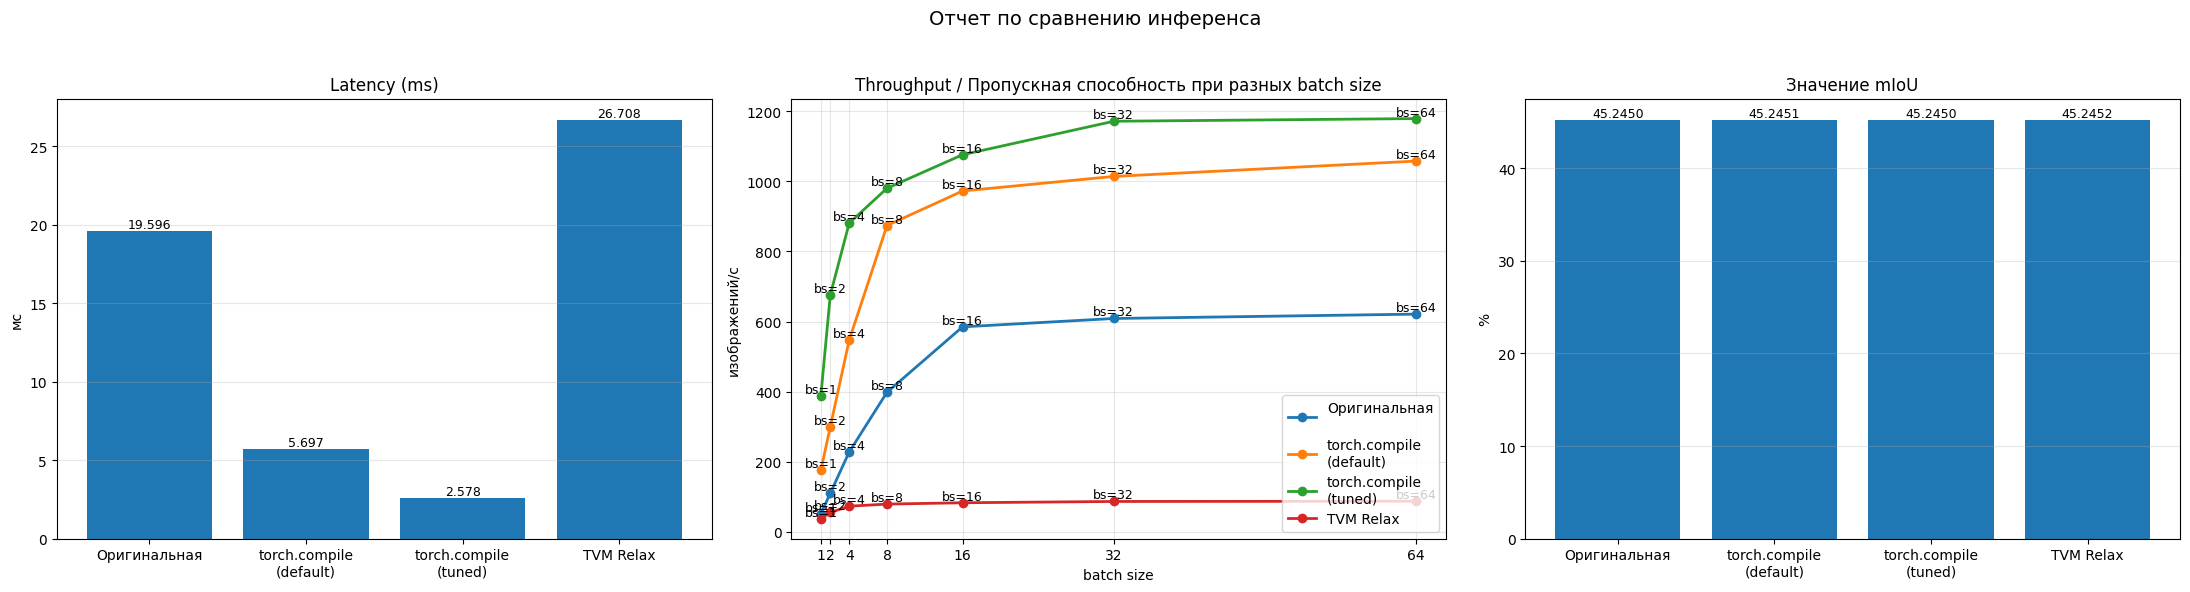

In [62]:
latency_df, throughput_df, metric_df, err_df = show_torch_compile_report(exp_compile_plus_tvm)